In [1]:
from pathlib import Path

import gffutils
from matplotlib import pyplot as plt
from matplotlib_venn import venn2
import numpy as np
import polars as pl
from safetensors.torch import load_file
from scipy.stats import entropy, mannwhitneyu, wilcoxon
import seaborn as sns
from statannotations.Annotator import Annotator

import torch

# Data loading

In [2]:
basepath = Path("/no_backup/rg/itrujnara/infer_chromosome/tensors")

In [3]:
size = 2**20
stride = size - 8192
chr_size = 46709983

In [4]:
chunks = []

for start in range(0,chr_size,stride):
    end = start + size
    filename = f"ch38_chr21_{start}_{end}_probs.safetensors"
    try:
        chunk_probs = load_file(basepath / filename)["probs"]
        chunks.append(chunk_probs)
    except FileNotFoundError:
        print(filename + " not found")

ch38_chr21_0_1048576_probs.safetensors not found
ch38_chr21_1040384_2088960_probs.safetensors not found
ch38_chr21_2080768_3129344_probs.safetensors not found
ch38_chr21_3121152_4169728_probs.safetensors not found


In [5]:
chunks_rc = []

for start in range(0,chr_size,stride):
    end = start + size
    filename = f"ch38_chr21_rc_{start}_{end}_probs.safetensors"
    try:
        chunk_probs = load_file(basepath / filename)["probs"]
        chunks_rc.append(chunk_probs)
    except FileNotFoundError:
        print(filename + " not found")

ch38_chr21_rc_0_1048576_probs.safetensors not found
ch38_chr21_rc_1040384_2088960_probs.safetensors not found
ch38_chr21_rc_2080768_3129344_probs.safetensors not found
ch38_chr21_rc_3121152_4169728_probs.safetensors not found


# Strand comparison

## Tensor computation

In [6]:
probs_fwd = torch.cat(chunks)[:-8192]

In [7]:
probs_fwd.shape

torch.Size([42532063, 4])

In [8]:
probs_rc = torch.cat(chunks_rc)[8192:]

In [9]:
probs_rc.shape

torch.Size([42532063, 4])

In [10]:
ic_fwd = 2 - entropy(probs_fwd, axis=1, base=2)

In [11]:
ic_rc = 2 - entropy(probs_rc, axis=1, base=2)

## IC distance

In [12]:
diff_real = ic_fwd - ic_rc

In [13]:
(diff_real ** 2).sum() ** 0.5

np.float32(2563.6008)

Text(0, 0.5, 'Count')

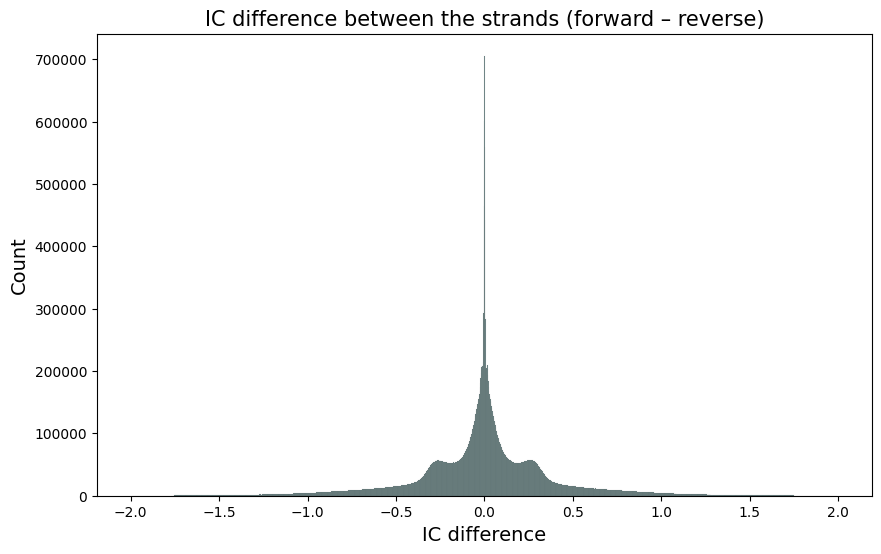

In [44]:
fig, ax = plt.subplots(figsize=(10,6))

sns.histplot(diff_real, ax=ax, color="#466365")
ax.set_title("IC difference between the strands (forward – reverse)", fontsize=15)
ax.set_xlabel("IC difference", fontsize=14)
ax.set_ylabel("Count", fontsize=14)

In [15]:
diff_real.mean()

np.float32(0.0006924849)

In [16]:
diff_real.std()

np.float32(0.39308986)

In [17]:
(diff_real > 0).mean()

np.float64(0.50105331123957)

In [18]:
(diff_real == 0.).mean()

np.float64(6.113035241201444e-07)

In [19]:
(diff_real < -0.5).mean()

np.float64(0.0785705127917261)

In [20]:
(diff_real > 0.5).mean()

np.float64(0.07894883913813444)

In [21]:
rng = np.random.default_rng(42)

ic_random = rng.permutation(ic_fwd)

In [22]:
((ic_fwd - ic_random)**2).sum()**0.5

np.float32(5722.4307)

In [23]:
dist_real_1 = entropy(probs_rc, probs_fwd, axis=1, base=2)

In [24]:
dist_real_2 = entropy(probs_fwd, probs_rc, axis=1, base=2)

In [25]:
dist_real_1.mean()

np.float32(1.4727612)

In [26]:
dist_real_1.std()

np.float32(2.2552545)

In [27]:
dist_real_2.mean()

np.float32(1.4686875)

In [28]:
dist_real_2.std()

np.float32(2.2442646)

In [29]:
torch.random.manual_seed(42)

idx = torch.randperm(probs_fwd.shape[0])

probs_random = probs_fwd[idx,:]

In [30]:
dist_random_1 = entropy(probs_random, probs_fwd, axis=1, base=2)

In [31]:
dist_random_1.mean()

np.float32(1.4178997)

In [32]:
dist_random_1.std()

np.float32(1.6190768)

In [33]:
dist_random_2 = entropy(probs_fwd, probs_random, axis=1, base=2)

In [34]:
dist_random_2.mean()

np.float32(1.4178963)

In [35]:
dist_random_2.std()

np.float32(1.6189867)

In [36]:
entropy([0.4,0.1,0.1,0.4], [0.3,0.2,0.2,0.3], base=2)

np.float64(0.1320299994230752)

## Top 10% intersection

In [37]:
quantile_fwd = np.quantile(ic_fwd, 0.9)
quantile_fwd

np.float32(1.6412253)

In [38]:
quantile_rc = np.quantile(ic_rc, 0.9)
quantile_rc

np.float32(1.6408143)

In [39]:
idx_fwd = np.argwhere(ic_fwd > quantile_fwd).flatten()
idx_fwd

array([  840291,   840294,   840298, ..., 42530252, 42530253, 42530254])

In [40]:
idx_rc = np.argwhere(ic_rc > quantile_rc).flatten()
idx_rc

array([  840274,   840275,   840291, ..., 42530238, 42530239, 42530241])

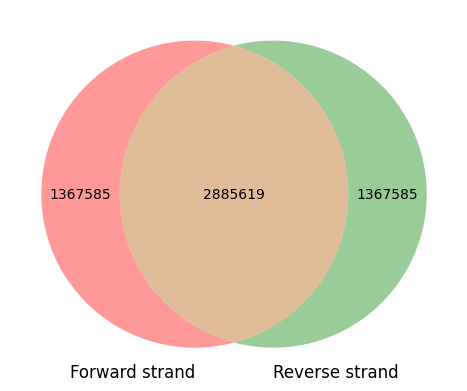

In [41]:
v = venn2((set(idx_fwd), set(idx_rc)), set_labels=("Forward strand", "Reverse strand"))